Some data preprocessing was needed (see preprocessing.py). During the preprocessing, we
- Remove all solved states.
- Remove all center tiles, as they never move and thus don't contribute anything.
- We decompose prime moves like U' into 3 * U, and decompose double moves like U2 into 2 * U

The PCA plot below shows that dimensionality reduction can't easily be done.

<Axes: >

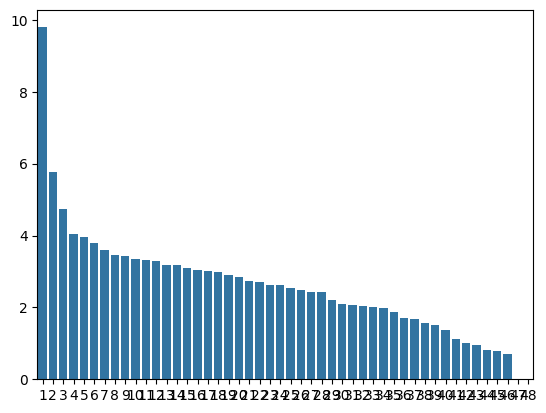

In [11]:
# PCA analysis shows that no significant dimensionality reduction is viable.

from CubeML.utils.model import load_dataset
import seaborn as sns
from sklearn.decomposition import PCA

data_df, moves_df = load_dataset("cfop-dataset-processed/dataset_no_prime.pkl")

pca = PCA()
pca.fit(data_df)

explained_var = pca.explained_variance_
sns.barplot(x=list(range(1, len(explained_var)+1)), y=explained_var)

In [6]:
from CubeML.utils.model import train_model, show_model_score
from CubeML.utils.cube import visualize_scramble, execute_move, is_cube_solved, visualize_scramble_terminal

model, X_test, y_test = train_model("random_forest", "cfop-dataset-processed/dataset_no_prime.pkl", 10000)

Best parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': 'balanced_subsample'}
Best score: 0.6459779203170949


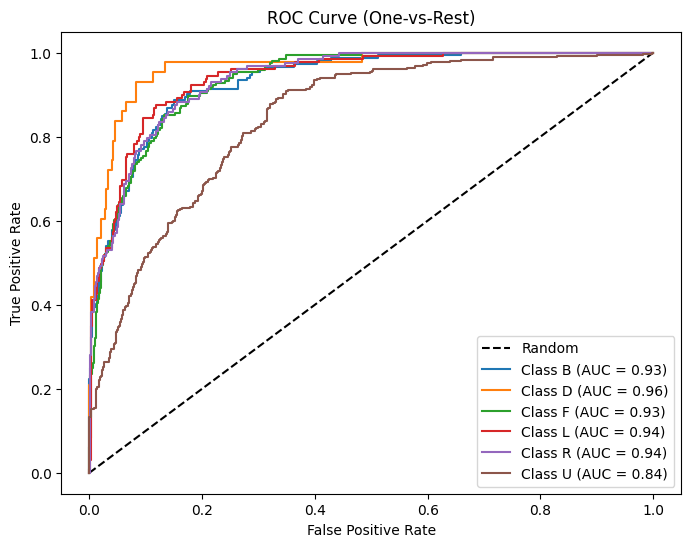

AUC score: 0.9255598374363573


In [7]:
show_model_score(model, X_test, y_test)

Now we can predict moves. Let's predict 200 random moves from the test set:

In [ ]:
state = X_test[:1]
visualize_scramble(state)

print(f"Prediction: {model.predict(state)[0]}")

Predicion: B


In [5]:
model.predict(X_test[:200])

array(['B', 'B', 'R', 'U', 'U', 'U', 'U', 'U', 'U', 'D', 'F', 'F', 'F',
       'B', 'D', 'R', 'R', 'L', 'R', 'U', 'U', 'U', 'F', 'U', 'R', 'F',
       'B', 'R', 'F', 'R', 'F', 'U', 'U', 'U', 'U', 'F', 'F', 'F', 'R',
       'L', 'F', 'F', 'F', 'U', 'F', 'U', 'R', 'U', 'U', 'R', 'U', 'F',
       'L', 'D', 'U', 'L', 'D', 'U', 'R', 'U', 'F', 'U', 'F', 'U', 'U',
       'B', 'L', 'U', 'U', 'U', 'R', 'L', 'U', 'L', 'U', 'B', 'U', 'U',
       'U', 'R', 'U', 'F', 'R', 'U', 'B', 'D', 'R', 'R', 'R', 'R', 'D',
       'U', 'U', 'D', 'U', 'F', 'D', 'R', 'U', 'L', 'B', 'U', 'U', 'R',
       'F', 'D', 'B', 'B', 'F', 'B', 'U', 'B', 'U', 'U', 'L', 'D', 'B',
       'B', 'U', 'F', 'L', 'U', 'U', 'R', 'U', 'R', 'U', 'F', 'U', 'L',
       'U', 'B', 'U', 'U', 'R', 'L', 'U', 'L', 'F', 'U', 'U', 'F', 'U',
       'B', 'U', 'R', 'L', 'B', 'U', 'L', 'U', 'U', 'B', 'R', 'B', 'L',
       'U', 'B', 'R', 'U', 'R', 'B', 'L', 'F', 'R', 'U', 'B', 'U', 'D',
       'F', 'F', 'U', 'U', 'U', 'R', 'U', 'F', 'U', 'L', 'L', 'B

Visualization functions:

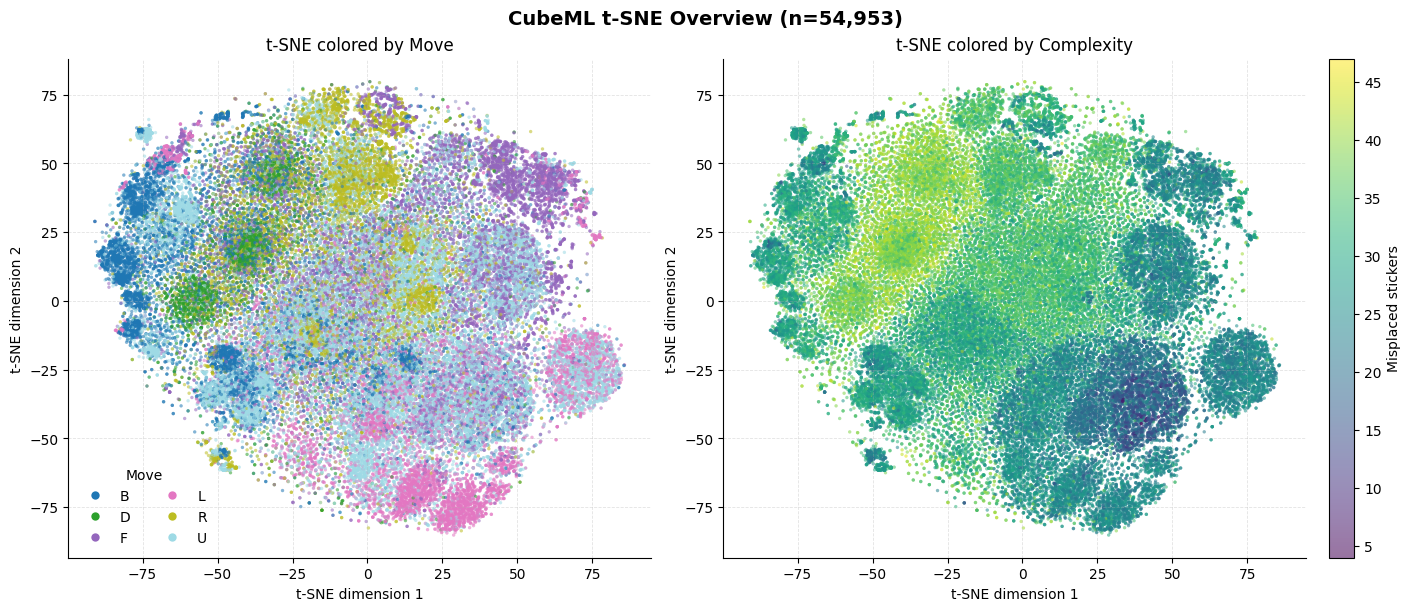

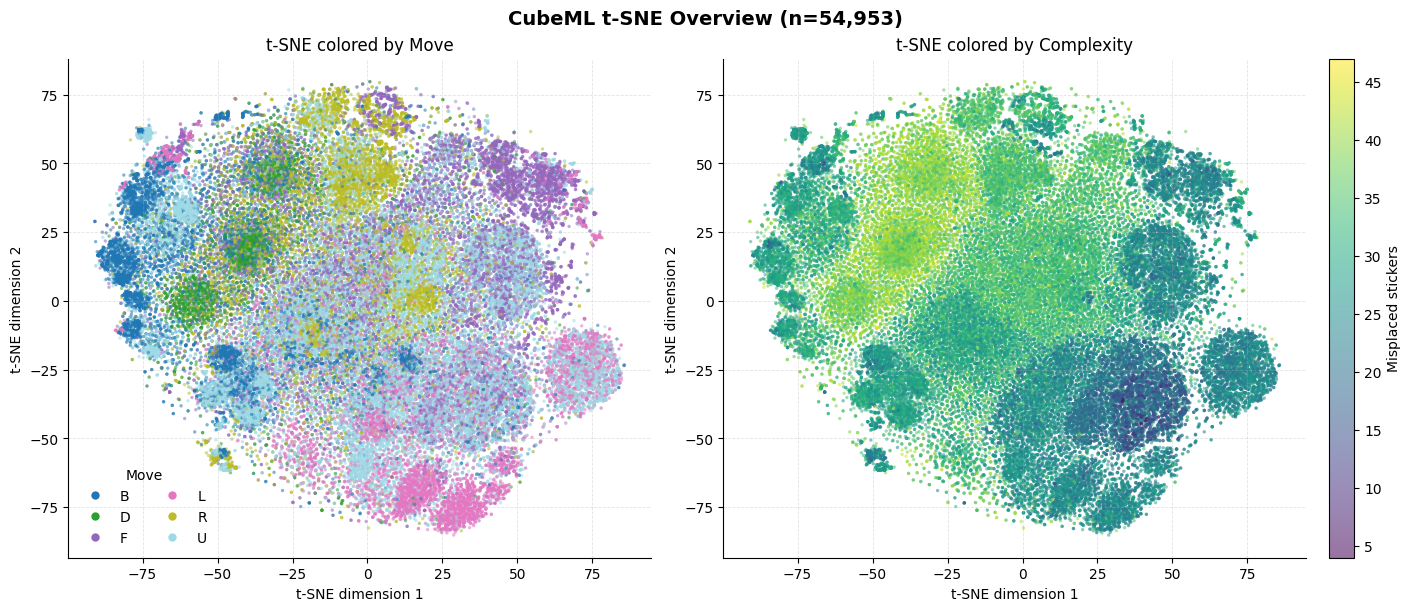

In [8]:
from CubeML.visualization.tsne import create_tsne_figure
from CubeML.utils.model import load_dataset
from CubeML.visualization.overview import compute_misplaced_sticker_counts
from CubeML.visualization.dataset_overview import extract_faces_from_dataset, DEFAULT_FACE_ORDER

data_df, moves_df = load_dataset("cfop-dataset-processed/dataset_no_prime.pkl")
df = data_df.assign(MOVE=moves_df)
face_order = extract_faces_from_dataset(df, preferred_order=DEFAULT_FACE_ORDER)

misplaced_stickers = compute_misplaced_sticker_counts(df, face_order=face_order)
create_tsne_figure(df, misplaced_stickers)